# Naive Bayes

## 1. Introdução

O **Naive Bayes** é um algoritmo de **aprendizado supervisionado** usado para **classificação**. Ele analisa as características de uma observação e calcula a probabilidade de ela pertencer a cada classe, escolhendo a classe mais provável. É usado, por exemplo, para identificar spam, classificar sentimentos e organizar documentos.

Seu funcionamento baseia-se no **Teorema de Bayes**: durante o treinamento, o modelo aprende a probabilidade de cada classe e de cada característica dentro dessas classes. O termo *naive* ("ingênuo") refere-se à suposição de que as características são **condicionalmente independentes** quando a classe é conhecida. Embora essa hipótese nem sempre seja verdadeira, ela simplifica os cálculos e torna o algoritmo rápido, e geralmente o resultado é correto.

O Naive Bayes é fácil de implementar, exige pouco custo computacional e costuma apresentar bom desempenho em dados com muitas variáveis, especialmente textos. Porém, pode ser menos eficaz quando as características são fortemente relacionadas.

## 2. O problema que queremos resolver

O Naive Bayes é estritamente utilizado para **Classificação** (binária ou multiclasse).

A pergunta central que o algoritmo faz é: **Dadas as evidências observadas (conjunto de features de uma instância), qual é a probabilidade estatística para cada classe possível, e qual classe maximiza essa probabilidade?**

Aplicações clássicas incluem:
- **Processamento de Linguagem Natural (NLP)**: Classificação de textos, análise de sentimentos.
- **Filtro de Spam**: Dada a ocorrência de certas palavras no e-mail, qual a probabilidade de ser Spam?
- **Diagnóstico Médico**: Sintomas isolados apontando para a probabilidade de uma patologia.

## 3. O Teorema de Bayes (Formalização)

A fundação do algoritmo reside na teoria das probabilidades. Seja um vetor de features $\mathbf{x} = (x_1, x_2, \dots, x_d)$ e uma classe alvo $C_k$, o Teorema de Bayes define:

$$\Large
P(C_k \vert{} \mathbf{x}) = \frac{P(\mathbf{x} \vert{} C_k) \cdot P(C_k)}{P(\mathbf{x})}
$$

Onde cada termo possui um significado específico em Machine Learning:
- **$P(C_k \vert{} \mathbf{x})$ (Probabilidade *A Posteriori*)**: A probabilidade de a instância ser da classe $C_k$ dado o vetor de features observadas $\mathbf{x}$. É o que queremos calcular.
- **$P(C_k)$ (Probabilidade *A Priori* / Prior)**: A probabilidade inerente da classe $C_k$ existir (frequência da classe no conjunto de treinamento).
- **$P(\mathbf{x} \vert{} C_k)$ (Verossimilhança / Likelihood)**: A probabilidade de observar as features $\mathbf{x}$ dado que a classe real é $C_k$.
- **$P(\mathbf{x})$ (Evidência)**: A probabilidade total de se observar o vetor de features $\mathbf{x}$ independentemente da classe. Serve apenas como um fator de normalização.

![Visualização do cálculo da probabilidade em Naive Bayes](../images/naive-bayes.png)

---
**Exemplo Numérico Prático:**
Imagine que queremos detectar se um e-mail é Spam ($C_k = Spam$) apenas verificando se ele contém a palavra 'Oferta' ($\mathbf{x} = \text{'Oferta'}$).
1. **$P(Spam)$ (Priori)**: Historicamente, sabemos que 1% de todos os e-mails recebidos são Spam. Logo, $P(Spam) = 0.01$.
2. **$P(\text{'Oferta'} \vert{} Spam)$ (Verossimilhança)**: Sabemos que 80% dos Spams contêm a palavra 'Oferta'. Logo, é $0.80$.
3. **$P(\text{'Oferta'})$ (Evidência)**: A palavra 'Oferta' aparece em 5% de todos os e-mails (sejam spam ou legítimos). Logo, é $0.05$.

Aplicando o teorema para descobrir a probabilidade do e-mail ser Spam sabendo que tem a palavra 'Oferta':
$$P(Spam \vert{} \text{'Oferta'}) = \frac{0.80 \times 0.01}{0.05} = 0.16$$
**Conclusão**: Há 16% de chance desse e-mail ser Spam.

## 4. A Suposição "Ingênua" (Naive)

O cálculo exato da Verossimilhança $P(\mathbf{x} \vert{} C_k) = P(x_1, x_2, \dots, x_d | C_k)$ exige recursos exponenciais e conjuntos de dados gigantescos para cobrir todas as combinações possíveis de features.

Para contornar isso, entra a suposição **Naive**: assumimos que todas as features $x_i$ são **mutuamente independentes**, dado que conhecemos a classe $C_k$. Pela regra da probabilidade independente, a probabilidade conjunta se quebra em um simples produtório de probabilidades individuais:

$$\Large
P(\mathbf{x} | C_k) \approx \prod_{i=1}^{d} P(x_i | C_k)
$$

---
**Exemplo Numérico Prático:**
Se o e-mail contém as palavras $\mathbf{x} = [\text{'Oferta'}, \text{'Urgente'}]$.

- **Sem a suposição Naive**: Precisaríamos calcular a probabilidade exata de 'Oferta' e 'Urgente' aparecerem *juntas* em Spams ($P(\text{'Oferta'}, \text{'Urgente'} \vert{} Spam)$). Isso exige tabelas massivas de coocorrência.
- **Com a suposição Naive**: Nós simplesmente multiplicamos as probabilidades isoladas: 
  $$P(\text{'Oferta'} | Spam) \times P(\text{'Urgente'} \vert{} Spam)$$
Assumimos que a presença da palavra 'Oferta' não altera em nada a chance da palavra 'Urgente' aparecer. Sabemos que na linguística real essa suposição é falsa (as palavras têm contexto), mas estatisticamente, essa "ingenuidade" funciona de forma brilhante para a classificação.

## 5. A Regra de Decisão: Como o modelo escolhe a classe?

A essência do Naive Bayes na hora de prever uma nova instância é a **comparação**. Ele calcula uma "pontuação" (probabilidade proporcional) para cada classe possível e escolhe a classe que obtiver o maior valor.

Como o denominador $P(\mathbf{x})$ é exatamente o mesmo para todas as classes testadas, nós o ignoramos. A regra de decisão consiste em encontrar a classe $\hat{y}$ que maximiza o numerador. Isso é conhecido na estatística como regra **MAP (Maximum A Posteriori)**:

$$\Large
\hat{y} = \underset{k \in \{1, \dots, K\}}{\operatorname{argmax}} \left[ P(C_k) \prod_{i=1}^{d} P(x_i \vert{} C_k) \right]
$$

---
**Exemplo Numérico Prático: A Decisão Final**
Vamos classificar um novo e-mail que contém apenas as palavras: **$\mathbf{x} = [\text{'Oferta'}, \text{'Urgente'}]$**. Temos duas classes possíveis: $Spam$ e $Normal$.

**Passo 1: Calcular a "Probabilidade" para a classe Spam**
- $P(Spam) = 0.01$ *(Probabilidade Priori: 1% dos e-mails são spam)*
- $P(\text{'Oferta'} \vert{} Spam) = 0.80$ *(80% dos spams têm a palavra oferta)*
- $P(\text{'Urgente'} \vert{} Spam) = 0.70$ *(70% dos spams têm a palavra urgente)*
- **Score do Spam** = $0.01 \times 0.80 \times 0.70 = \mathbf{0.0056}$

**Passo 2: Calcular a "Probabilidade" para a classe Normal**
- $P(Normal) = 0.99$ *(Probabilidade Priori: 99% dos e-mails são normais)*
- $P(\text{'Oferta'} \vert{} Normal) = 0.05$ *(Apenas 5% dos e-mails normais têm a palavra oferta)*
- $P(\text{'Urgente'} \vert{} Normal) = 0.01$ *(Apenas 1% dos e-mails normais têm a palavra urgente)*
- **Score do Normal** = $0.99 \times 0.05 \times 0.01 = \mathbf{0.000495}$

**Passo 3: A Decisão (Argmax)**
O modelo compara os resultados dos dois mundos possíveis:
$0.0056$ (Spam) **>** $0.000495$ (Normal).
Logo, o modelo decreta: **Este e-mail é Spam**, pois esta classe maximizou a probabilidade a posteriori.

---
### Prevenção de Underflow (Aplicaçao do Logaritmo)
Matematicamente, se fôssemos multiplicar centenas de probabilidades (valores entre 0 e 1, como num texto de 500 palavras), o resultado tenderia rapidamente a zero absoluto, excedendo o limite de precisão do computador (*Numerical Underflow*).

Para resolver isso, os algoritmos aplicam o **logaritmo natural** ($\log$). Como o logaritmo cresce de forma constante, a classe que tem a maior probabilidade original também terá o maior logaritmo. O produtório então se transforma em um **somatório seguro**:

$$\Large
\hat{y} = \underset{k}{\operatorname{argmax}} \left[ \log P(C_k) + \sum_{i=1}^{d} \log P(x_i | C_k) \right]
$$

## 6. Variantes do Naive Bayes

A forma de calcular a verossimilhança $P(x_i | C_k)$ depende do tipo de dado de suas features. Existem 3 tipos fundamentais:

### 6.1. Gaussian Naive Bayes (Para dados contínuos)
Assume-se que os dados numéricos contínuos em cada feature seguem uma distribuição Normal (Gaussiana). Em treinamento, o modelo calcula apenas a Média ($\mu$) e a Variância ($\sigma^2$) de cada feature para cada classe. A probabilidade de um novo dado é extraída da Função de Densidade de Probabilidade (PDF):
$$\Large P(x_i | C_k) = \frac{1}{\sqrt{2\pi\sigma_{k,i}^2}} \exp\left(-\frac{(x_i - \mu_{k,i})^2}{2\sigma_{k,i}^2}\right)$$

![Naive Bayes quando os dados são contínuos, e não categóricos](../images/naive-bayes-dados_continuos.png)

### 6.2. Multinomial Naive Bayes (Para dados discretos/frequência)
Ideal para contagem de ocorrências (ex: contagem de quantas vezes cada palavra apareceu em um documento usando *Bag of Words*). Modela a distribuição de frequências.

### 6.3. Bernoulli Naive Bayes (Para dados binários)
Exige que as features sejam booleanas (1 ou 0). Útil em NLP para identificar apenas se uma palavra apareceu ou não no texto (presença/ausência), ignorando quantas vezes ela se repetiu.

## 7. Frequência Zero e o Suavizador de Laplace

**O Problema da Frequência Zero**: Nas variantes de texto (Multinomial/Bernoulli), se um modelo encontrar uma palavra em teste que **nunca** apareceu no treinamento para uma classe específica $C_k$, a probabilidade $P(x_{novo} | C_k)$ será igual a 0. Devido à regra do produtório, multiplicar tudo por 0 fará a probabilidade inteira dessa classe "zerar" abruptamente, o que é um erro fatal.

**A Solução Matemática: Laplace Smoothing**: Adiciona-se um valor pseudo-contábil $\alpha$ a todas as frequências estimadas. Sejam $N_{k,i}$ a contagem da feature $i$ na classe $k$, $N_k$ as contagens totais na classe $k$, e $d$ o total de features (se for texto, tamanho do vocabulário / palavras únicas):

$$\Large
\hat{\theta}_{k,i} = \frac{N_{k,i} + \alpha}{N_k + \alpha d}
$$

Na prática, o hiperparâmetro mais comum é $\alpha = 1$ (Laplace Smoothing), ou $\alpha < 1$ (Lidstone Smoothing). Isso garante que nenhuma probabilidade caia para zero absoluto.

![O suavizador/estimador de Laplace em Naive Bayes](../images/naive-bayes-laplace.png)

---
**Exemplo Numérico Prático:**
Suponha que estamos classificando e-mails legítimos ($C_k = Normal$). A palavra 'Criptomoeda' **nunca** apareceu nos e-mails legítimos de treino. Logo, $N_{Normal, \text{'Cripto'}} = 0$.
O total de palavras nos e-mails normais somou 1000 ($N_k = 1000$) e nosso vocabulário total conhecido pelo modelo tem 500 palavras únicas ($d = 500$).
- **Sem Laplace**: $P(\text{'Criptomoeda'} | Normal) = \frac{0}{1000} = 0$. (Zera tudo!).
- **Com Laplace ($\alpha = 1$)**: $P(\text{'Criptomoeda'} | Normal) = \frac{0 + 1}{1000 + 1 \times 500} = \frac{1}{1500} \approx 0.00067$. (O problema do zero foi resolvido sem distorcer demais os dados).

## 8. Como avaliar o modelo

Por ser um modelo restrito à classificação, a validação segue o padrão das métricas da **Matriz de Confusão**:

- **Acurácia**: Proporção de predições corretas no total.
- **Precisão (Precision)**: Avalia o viés de "falso alarme / falso positivo" (Dos que o modelo disse que era Spam, quantos realmente eram?).
- **Recall (Sensibilidade)**: Avalia o viés de falso negativo. Avalia a capacidade de encontrar positivos (De todos os Spams reais, quantos o modelo conseguiu detectar?).
- **F1-Score**: Média harmônica entre Precisão e Recall (ideal para classes desbalanceadas).

## 9. Vantagens e limitações

**Vantagens:**
- **Velocidade de Treinamento**: Diferente da Regressão Logística, que exige otimização iterativa complexa (Gradiente Descendente), o Naive Bayes treina calculando puramente médias, frequências e variâncias em tempo linear $\mathcal{O}(N \times d)$. É extremamente rápido.
- Escala perfeitamente para milhares ou milhões de features (ótimo para Big Data e Textos).
- Não sofre severamente com a Maldição da Dimensionalidade como o KNN.

**Limitações:**
- **Pressuposto de Independência Falso**: As features na vida real são frequentemente correlacionadas. Quando a correlação é muito forte, o algoritmo tende a acentuar confianças erradas.
- **Péssimo Estimador Absoluto**: Como a suposição de independência falha na vida real, a porcentagem exata retornada por métodos como `predict_proba()` possui pouca calibração probabilística real (empurra as probabilidades fortemente para extremos, perto de 0 ou 1). No entanto, mantém a boa "ordenação", prestando-se perfeitamente para decidir quem ganha (ranqueamento), e é útil para classificação, embora a probabilidade calculada seja pouco confiável.

## 10. Naive Bayes no fluxo de Machine Learning

1. Definir o problema.
2. Tratamento de dados (No caso de texto: Tokenização, Stopwords, aplicação de TF-IDF ou CountVectorizer).
3. Separação de Treino e Teste.
4. Ao contrário do KNN, **não é obrigatório escalonar** (Z-score/Min-max) para as variantes Multinomial/Bernoulli. Contudo, escalonar pode estabilizar o cálculo das variâncias na variante Gaussian NB.
5. Validação cruzada (testar diferentes valores do suavizador $\alpha$ no Multinomial, se houver).
6. Avaliar as métricas na base de Teste.

## 11. Exemplo prático simples

Nesta seção, aplicaremos o algoritmo **Gaussian Naive Bayes** do `scikit-learn` usando o dataset **Iris**, carregado do arquivo `data/iris.csv` (como as features são numéricas contínuas, Gaussian NB é uma variante adequada). O objetivo é classificar as três espécies de íris.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Carregando e inspecionando a base de dados Iris.

In [2]:
data_path = Path("../data/iris.csv")
df = pd.read_csv(data_path)
df.drop(columns=["Id"], inplace=True)

X = df.drop(columns=["Species"])
y = df["Species"]

In [3]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


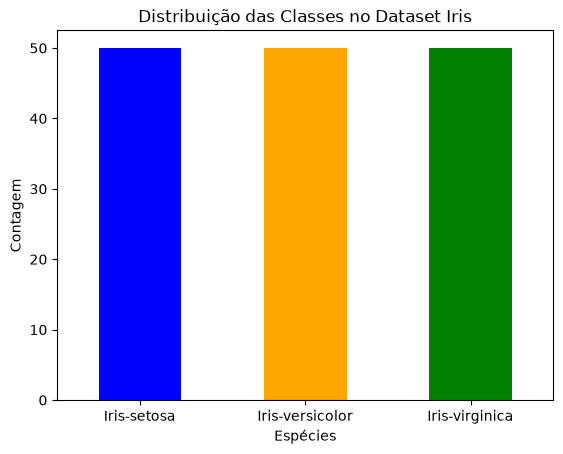

In [4]:
df["Species"].value_counts().plot(kind='bar', color=['blue', 'orange', 'green'])
plt.title("Distribuição das Classes no Dataset Iris")
plt.xlabel("Espécies")
plt.ylabel("Contagem")
plt.xticks(rotation=0)
plt.show()

Divisão entre dados de treino e teste.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Treinamento do modelo. O `GaussianNB` aprende as médias e variâncias das features numéricas para cada espécie.

In [6]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia do Gaussian Naive Bayes (Scikit-Learn): {acc * 100:.2f}%")

Acurácia do Gaussian Naive Bayes (Scikit-Learn): 97.78%


Relatório e avaliação

In [7]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))


Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.93      1.00      0.96        13

       accuracy                           0.98        45
      macro avg       0.98      0.97      0.97        45
   weighted avg       0.98      0.98      0.98        45

Matriz de Confusão:
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


## 12. Exemplo prático construído do zero (*From Scratch*)

Para aplicar a teoria, implementaremos o **Gaussian Naive Bayes** do zero, usando NumPy e o dataset de câncer de mama, que contém features com dados contínuos.

A implementação estima as probabilidades a priori de cada classe e as médias e variâncias de cada feature para cada classe. Em seguida, calcula as densidades gaussianas e classifica cada amostra pela maior probabilidade posterior.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

In [9]:
data_path = Path("../data/cancer.csv")
df = pd.read_csv(data_path)
df.drop(columns=["id", "Unnamed: 32"], inplace=True)

In [10]:
df.shape

(569, 31)

In [11]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


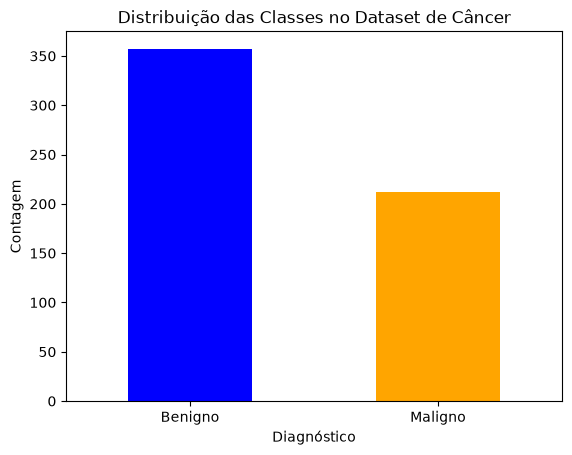

In [12]:
df["diagnosis"].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title("Distribuição das Classes no Dataset de Câncer")
plt.xlabel("Diagnóstico")
plt.ylabel("Contagem")
plt.xticks(ticks=[0, 1], labels=["Benigno", "Maligno"])
plt.xticks(rotation=0)
plt.show()

In [13]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
class GaussianNaiveBayes:
    def fit(self, X, y):
        self.classes = np.unique(y) # contabiliza as classes únicas
        self.y_priors = [len(y[y == classe]) / len(y) for classe in self.classes] # calcula a probabilidade a priori de cada classe
        self.classes_means = [X[y == classe].mean() for classe in self.classes] # calcula a média de cada feature para cada classe. Retorna uma lista de Series, cada uma representando a média das features para uma classe específica
        self.classes_std = [X[y == classe].std() for classe in self.classes] # calcula o desvio padrão de cada feature para cada classe. Retorna uma lista de Series, cada uma representando o desvio padrão das features para uma classe específica

    def likelihood(self, row, class_idx):
        likelihood = 1
        for feature in row.index: # itera sobre os nomes das features da linha de entrada (row). row é uma Series representando os valores das features para uma linha específica do DataFrame X, e row.index retorna os nomes das colunas (features) do DataFrame X
            mean = self.classes_means[class_idx][feature] # calcula a média da feature específica para a classe atual considerada (class_idx)
            std = self.classes_std[class_idx][feature] # calcula o desvio padrão da feature específica para a classe atual considerada (class_idx)
            likelihood *= (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(-((row[feature] - mean) ** 2) / (2 * std ** 2)) # calcula a probabilidade de cada feature dado a classe atual considerada (class_idx) usando a fórmula da Distribuição Normal. A probabilidade Likelihood total é o produto das probabilidades individuais das features

        return likelihood

    def predict(self, X):
        y_pred = []

        for _, row in X.iterrows(): # itera sobre cada linha do DataFrame X. iterrows() retorna um gerador que produz pares (índice, linha), onde linha é uma Series representando os valores das features para aquela linha específica do DataFrame X
            posteriors = [] # lista para armazenar as probabilidades a posteriori calculadas para cada classe, considerando a linha de entrada (row) atual

            for i in range (len(self.classes)): # itera sobre o índice de cada classe possível
                likelihood = self.likelihood(row, i) # calcula a probabilidade de cada feature dado a classe atual considerada (i)
                posterior = likelihood * self.y_priors[i] # calcula a probabilidade a posteriori usando o Teorema de Bayes. A probabilidade a posteriori é proporcional ao produto da probabilidade Likelihood e da probabilidade a priori
                posteriors.append(posterior) # adiciona a probabilidade a posteriori calculada para a classe atual à lista de probabilidades a posteriori da linha atual

            y_pred.append(self.classes[np.argmax(posteriors)]) # classifica a linha atual como o nome da classe com a maior probabilidade a posteriori calculada

        return np.array(y_pred)

In [15]:
nb = GaussianNaiveBayes()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test) 

acc = np.mean(y_pred == y_test) * 100 
print(f"Acurácia do Gaussian Naive Bayes (implementação própria): {acc:.2f}%")

Acurácia do Gaussian Naive Bayes (implementação própria): 96.49%


## 13. Conclusão

O **Naive Bayes** utiliza o Teorema de Bayes para calcular a probabilidade posterior de cada classe dada as features e escolher a classe que maximiza essa probabilidade, seguindo a regra MAP. Sua principal simplificação é assumir independência condicional entre as features, permitindo decompor a verossimilhança conjunta em um produto de probabilidades individuais.

Embora essa hipótese raramente seja totalmente verdadeira, ela torna o modelo matematicamente simples, rápido e eficiente. A escolha da variante — como Gaussian, Multinomial ou Bernoulli — deve considerar a natureza dos dados, enquanto o suavizador de Laplace evita probabilidades nulas. Assim, o Naive Bayes oferece uma aplicação direta da teoria da probabilidade à classificação.